# 🫁 Pneumonia Detection Using Deep Learning

Pneumonia is a serious respiratory infection that inflames the air sacs in one or both lungs, often leading to difficulty in breathing, chest pain, fever, and fatigue. Early and accurate diagnosis is critical, as delayed treatment can result in severe complications, especially for children, the elderly, and immunocompromised individuals.

In this project, we leverage **deep learning and convolutional neural networks (CNNs)** to automatically detect pneumonia from chest X-ray images. By learning visual patterns associated with infected and healthy lungs, the model aims to assist medical professionals with fast and reliable screening.

## 🎯 Objectives
- Build a neural network capable of classifying chest X-rays as **Pneumonia** or **Normal**  
- Achieve strong generalization on unseen patient data  
- Demonstrate how AI can support medical decision-making

## 🧠 Approach
- Preprocess and normalize chest X-ray images  
- Train a CNN-based classifier on labeled medical images  
- Evaluate performance using accuracy and loss metrics  

## 💡 Why This Matters
Manual interpretation of X-rays is time-consuming and prone to human error. An automated system can:
- Reduce diagnostic workload  
- Provide rapid preliminary assessments  
- Improve accessibility of healthcare in low-resource settings  

This project serves as a practical example of applying deep learning to real-world healthcare challenges.


# Imports & Configuration


In [ ]:
import os
import shutil
import random
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split


# Check Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

Using Device: cuda


# Copy Data to Local Runtime (Speed Boost)

In [ ]:
# Source (Google Drive)
drive_path = '/content/drive/MyDrive/chest_xray'

# Destination (Colab Local Disk)
local_path = '/content/chest_xray_local'

if not os.path.exists(local_path):
    print(f"Copying data from {drive_path} to {local_path}...")
    print("This may take 1-2 minutes, but will save ~30 mins of training time.")
    shutil.copytree(drive_path, local_path)
    print("Copy complete!")
else:
    print("Data already exists locally. Skipping copy.")

# Set paths for the rest of the notebook
train_dir = os.path.join(local_path, 'train')
test_dir = os.path.join(local_path, 'test')
# Note: We ignore the original 'val' folder because it is too small.

Copying data from /content/drive/MyDrive/chest_xray to /content/chest_xray_local...
This may take 1-2 minutes, but will save ~30 mins of training time.
Copy complete!


# Data Loading and Splitting


In [ ]:
# 1. Define Transforms
# Augmentation for Training
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),           # Rotate +/- 15 degrees
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Lighting shift
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Clean transform for Validation and Test
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Load the Full Training Folder
full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)

# 3. Create a Proper Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# IMPORTANT: Remove augmentation from Validation set
val_dataset.dataset = copy.deepcopy(full_train_dataset) # Copy data
val_dataset.dataset.transform = val_test_transforms     # Apply clean transform

# 4. Load Test Data
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

# 5. Create Data Loaders
BATCH_SIZE = 32
dataloaders = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'val': DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    'test': DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
}

class_names = full_train_dataset.classes
print(f"Class Names: {class_names}")
print(f"Training Samples: {len(train_dataset)}")
print(f"Validation Samples: {len(val_dataset)}")
print(f"Test Samples: {len(test_dataset)}")

Class Names: ['NORMAL', 'PNEUMONIA']
Training Samples: 4175
Validation Samples: 1044
Test Samples: 624


# Calculate Class Weights


In [ ]:
# Count samples in the original folder
n_normal = len(os.listdir(os.path.join(train_dir, 'NORMAL')))
n_pneumonia = len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))
total = n_normal + n_pneumonia

# Weighted Loss Formula: Total / (2 * Class_Count)
weight_normal = total / (2.0 * n_normal)
weight_pneumonia = total / (2.0 * n_pneumonia)

class_weights = torch.tensor([weight_normal, weight_pneumonia]).to(device)

print(f"Normal Count: {n_normal}, Pneumonia Count: {n_pneumonia}")
print(f"Applying Class Weights -> Normal: {weight_normal:.2f}, Pneumonia: {weight_pneumonia:.2f}")

Normal Count: 1342, Pneumonia Count: 3879
Applying Class Weights -> Normal: 1.95, Pneumonia: 0.67


# Build Model

In [ ]:
def build_model():
    # Load Pretrained ResNet18
    model = models.resnet18(pretrained=True)

    # 1. Freeze early layers (Layer 1-3)
    # We allow Layer 4 to train (fine-tuning)
    for name, child in model.named_children():
        if name in ['layer4', 'fc']:
            for param in child.parameters():
                param.requires_grad = True
        else:
            for param in child.parameters():
                param.requires_grad = False

    # 2. Modify the output layer (Head)
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),      # Drop 50% of neurons to prevent overfitting
        nn.Linear(num_ftrs, 2)
    )

    return model.to(device)

model = build_model()

# 3. Loss Function (With Class Weights)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# 4. Optimizer (Low learning rate for fine-tuning)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 136MB/s]


# Training Loop

In [ ]:
num_epochs = 10
best_acc = 0.0
train_loss_hist, val_loss_hist = [], []
train_acc_hist, val_acc_hist = [], []

print("Starting Training...")
start_time = time.time()

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(dataloaders[phase].dataset)
        epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # Save history
        if phase == 'train':
            train_loss_hist.append(epoch_loss)
            train_acc_hist.append(epoch_acc.item())
        else:
            val_loss_hist.append(epoch_loss)
            val_acc_hist.append(epoch_acc.item())

            # Save Deep Copy of Model if it's the best
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), 'best_model.pth')

time_elapsed = time.time() - start_time
print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
print(f'Best Validation Acc: {best_acc:.4f}')

Starting Training...

Epoch 1/10
----------
train Loss: 0.1734 Acc: 0.9301
val Loss: 0.0733 Acc: 0.9732

Epoch 2/10
----------
train Loss: 0.0835 Acc: 0.9646
val Loss: 0.0596 Acc: 0.9818

Epoch 3/10
----------
train Loss: 0.0694 Acc: 0.9751
val Loss: 0.0520 Acc: 0.9847

Epoch 4/10
----------
train Loss: 0.0626 Acc: 0.9758
val Loss: 0.0541 Acc: 0.9818

Epoch 5/10
----------
train Loss: 0.0459 Acc: 0.9835
val Loss: 0.0616 Acc: 0.9818

Epoch 6/10
----------
train Loss: 0.0465 Acc: 0.9842
val Loss: 0.0432 Acc: 0.9847

Epoch 7/10
----------
train Loss: 0.0455 Acc: 0.9854
val Loss: 0.0521 Acc: 0.9808

Epoch 8/10
----------
train Loss: 0.0487 Acc: 0.9818
val Loss: 0.0499 Acc: 0.9828

Epoch 9/10
----------
train Loss: 0.0324 Acc: 0.9897
val Loss: 0.0358 Acc: 0.9875

Epoch 10/10
----------
train Loss: 0.0280 Acc: 0.9887
val Loss: 0.0394 Acc: 0.9866

Training complete in 13m 52s
Best Validation Acc: 0.9875


# Plot training results

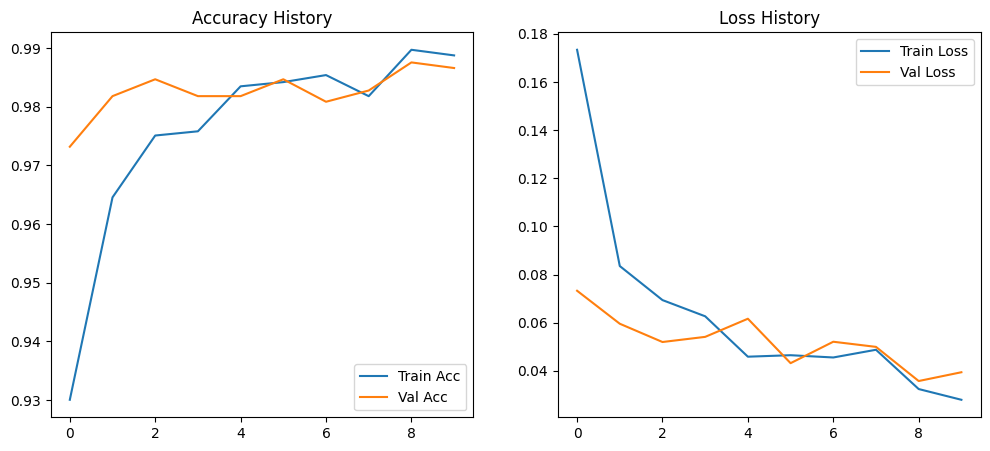

In [ ]:
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(train_acc_hist, label='Train Acc')
plt.plot(val_acc_hist, label='Val Acc')
plt.title('Accuracy History')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(train_loss_hist, label='Train Loss')
plt.plot(val_loss_hist, label='Val Loss')
plt.title('Loss History')
plt.legend()

plt.show()

# Final Evaluation

Evaluating on Test Set...

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.58      0.73       234
   PNEUMONIA       0.80      0.99      0.88       390

    accuracy                           0.84       624
   macro avg       0.89      0.79      0.81       624
weighted avg       0.87      0.84      0.83       624



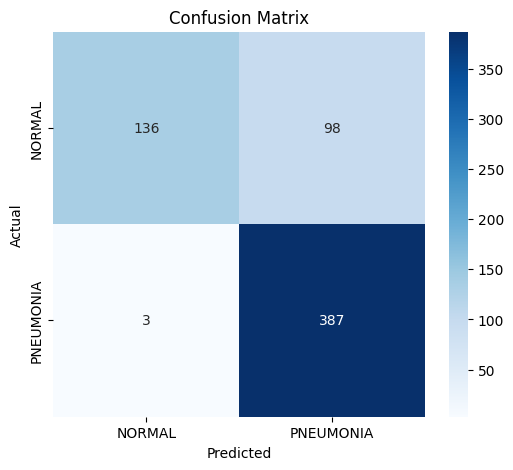

In [ ]:
# 1. Load Best Weights
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

y_true = []
y_pred = []

# 2. Predict on Test Set
print("Evaluating on Test Set...")
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 3. Generate Metrics
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Single Image Prediction

In [ ]:
def predict_image(image_path, model):
    try:
        # Load and Transform
        image = Image.open(image_path).convert('RGB')
        transform = val_test_transforms
        image_tensor = transform(image).unsqueeze(0).to(device)

        # Predict
        model.eval()
        with torch.no_grad():
            outputs = model(image_tensor)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

        # Result
        class_idx = preds.item()
        confidence = probs[0][class_idx].item()
        predicted_label = class_names[class_idx]

        # Display
        plt.imshow(image)
        plt.title(f"Prediction: {predicted_label} ({confidence:.2%})")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error processing image: {e}")

# Example Usage:
# test_img_path = os.path.join(test_dir, 'PNEUMONIA', os.listdir(os.path.join(test_dir, 'PNEUMONIA'))[0])
# predict_image(test_img_path, model)

In [ ]:
from google.colab import files

# 1. Define the filename
model_save_name = 'pneumonia_resnet18_weights.pth'
path = f"/content/{model_save_name}"

# 2. Save the State Dictionary (Best Practice)
print(f"Saving model weights to {path}...")
torch.save(model.state_dict(), path)

# 3. Trigger Download to your Local Computer
print("Triggering download...")
files.download(path)

print(f"Model saved! File size: {os.path.getsize(path) / 1e6:.2f} MB")

Saving model weights to /content/pneumonia_resnet18_weights.pth...
Triggering download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model saved! File size: 44.79 MB


In [ ]:
model_pat